
MODULE 1 : CLASS LABELING

FIRST 5 ROWS
   _id                 time    val
0    1  2016-08-18T10:55:00  50.00
1    2  2016-08-18T11:00:00  50.12
2    3  2016-08-18T11:05:00  50.00
3    4  2016-08-18T11:10:00  50.00
4    5  2016-08-18T11:15:00  51.92

CLASS LABELS CREATED SUCCESSFULLY

CLASS DISTRIBUTION
Class_Label
Normal      23449
Warning      2006
Critical      932
Name: count, dtype: int64

PARQUET FILE SAVED

MODULE 2 : FEATURE ENGINEERING

FEATURES CREATED SUCCESSFULLY

MODULE 3 : MODEL EXECUTION

MODEL TRAINED SUCCESSFULLY

PREDICTIONS COMPLETED

MODULE 4 : PERFORMANCE EXPLORATION

OVERALL ACCURACY
100.00%

CONFUSION MATRIX
[[ 196    0    0]
 [   0 4680    0]
 [   0    0  402]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       196
      Normal       1.00      1.00      1.00      4680
     Warning       1.00      1.00      1.00       402

    accuracy                           1.00      5278
   macro a

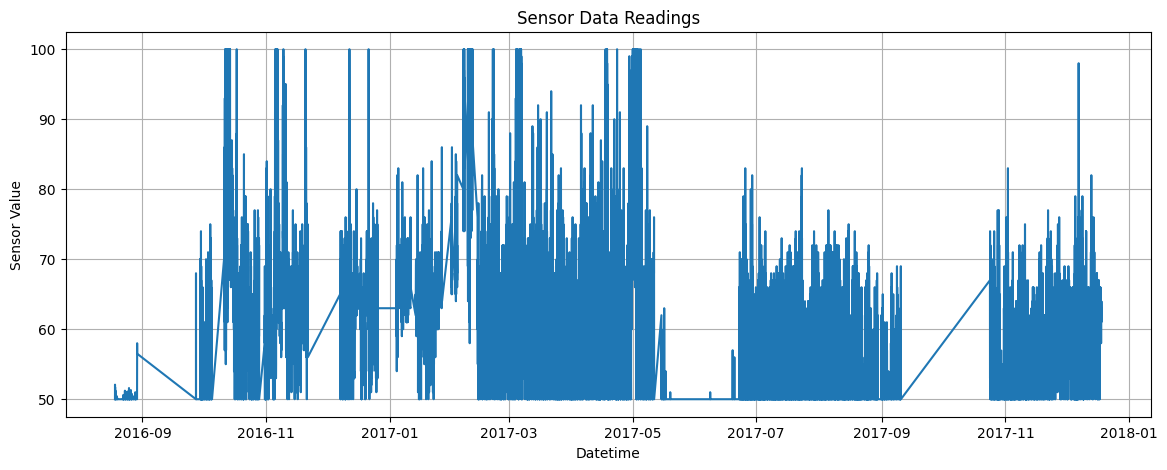

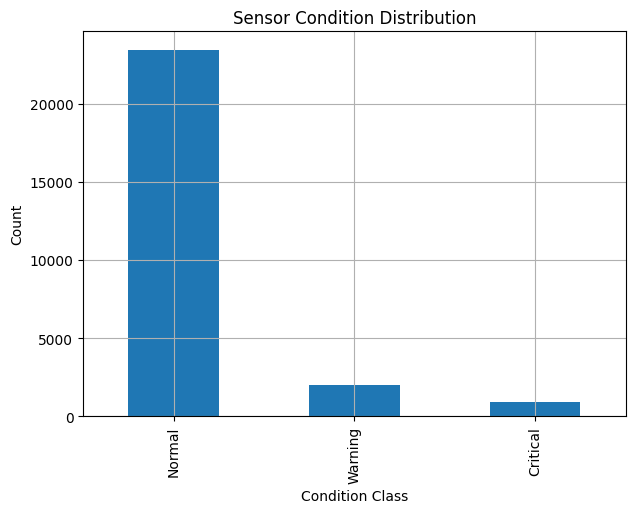


PR_26 PRACTICAL COMPLETED


In [2]:
# ==========================================
# PR_26
# Analytical Models for Dataset Classification
# Using Sensor Data Dataset
# ==========================================

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ==========================================
# MODULE 1 :
# CLASS DEFINITION AND LABELING
# ==========================================

print("\n===================================")
print("MODULE 1 : CLASS LABELING")
print("===================================")

"""
DEFINITION:
This module assigns predefined classes
to sensor readings based on statistical
patterns using standard deviation.
"""

# ---------- LOAD DATASET ----------

df = pd.read_csv("sensor_data.csv")

print("\nFIRST 5 ROWS")
print(df.head())

# ---------- DATETIME CONVERSION ----------

df['time'] = pd.to_datetime(
    df['time'],
    errors='coerce'
)

# Remove invalid datetime rows
df = df.dropna(subset=['time'])

# ---------- SET TIME INDEX ----------

df = df.set_index('time')

# Sort sequentially
df = df.sort_index()

# ---------- CONVERT SENSOR VALUES ----------

df['val'] = pd.to_numeric(
    df['val'],
    errors='coerce'
)

# Remove invalid rows
df = df.dropna(subset=['val'])

# Keep required column
df = df[['val']]

# ---------- CLASS ASSIGNMENT LOGIC ----------

"""
CLASS DEFINITIONS

NORMAL      = Stable sensor condition
WARNING     = Slight abnormal variation
CRITICAL    = Dangerous abnormal condition
"""

# Calculate statistical boundaries
mean = df['val'].mean()

std = df['val'].std()

# Define class conditions
conditions = [

    # Normal Condition
    (df['val'] <= mean + std),

    # Warning Condition
    (
        (df['val'] > mean + std) &
        (df['val'] <= mean + 2 * std)
    ),

    # Critical Condition
    (df['val'] > mean + 2 * std)

]

# Assign class labels
df['Class_Label'] = np.select(
    conditions,
    [
        'Normal',
        'Warning',
        'Critical'
    ],
    default='Normal'
)

print("\nCLASS LABELS CREATED SUCCESSFULLY")

print("\nCLASS DISTRIBUTION")
print(df['Class_Label'].value_counts())

# ---------- SAVE LABELED DATA ----------

df.to_parquet(
    "labeled_training_data.parquet",
    compression='snappy'
)

print("\nPARQUET FILE SAVED")


# ==========================================
# MODULE 2 :
# FEATURE ENGINEERING
# ==========================================

print("\n===================================")
print("MODULE 2 : FEATURE ENGINEERING")
print("===================================")

"""
DEFINITION:
Feature engineering creates derived
patterns from raw sensor values.
"""

# ---------- DELTA FEATURE ----------

"""
Delta represents the speed of change
between sensor readings.
"""

df['Delta'] = (
    df['val']
    .diff()
    .fillna(0)
)

# ---------- ROLLING VARIANCE FEATURE ----------

"""
Rolling variance measures
signal stability over time.
"""

df['Rolling_Var'] = (
    df['val']
    .rolling(window=10)
    .var()
    .fillna(0)
)

# ---------- ROLLING MEAN FEATURE ----------

"""
Rolling mean represents
local average behavior.
"""

df['Rolling_Mean'] = (
    df['val']
    .rolling(window=10)
    .mean()
    .fillna(0)
)

print("\nFEATURES CREATED SUCCESSFULLY")

# ---------- FINAL FEATURE MATRIX ----------

X = df[[
    'val',
    'Delta',
    'Rolling_Var',
    'Rolling_Mean'
]]

# Target variable
y = df['Class_Label']


# ==========================================
# MODULE 3 :
# MODEL EXECUTION
# ==========================================

print("\n===================================")
print("MODULE 3 : MODEL EXECUTION")
print("===================================")

"""
DEFINITION:
Random Forest Classifier learns
patterns from labeled sensor data
and predicts predefined classes.
"""

# ---------- TRAIN TEST SPLIT ----------

"""
80% Training Data
20% Testing Data
"""

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

# ---------- RANDOM FOREST MODEL ----------

clf = RandomForestClassifier(

    n_estimators=150,

    max_depth=10,

    random_state=42

)

# ---------- MODEL TRAINING ----------

clf.fit(

    X_train,

    y_train

)

print("\nMODEL TRAINED SUCCESSFULLY")

# ---------- CLASS PREDICTION ----------

y_pred = clf.predict(X_test)

print("\nPREDICTIONS COMPLETED")


# ==========================================
# MODULE 4 :
# PERFORMANCE EXPLORATION
# ==========================================

print("\n===================================")
print("MODULE 4 : PERFORMANCE EXPLORATION")
print("===================================")

"""
DEFINITION:
Evaluation metrics validate the
classification reliability of the model.
"""

# ---------- ACCURACY SCORE ----------

accuracy = accuracy_score(

    y_test,

    y_pred

)

print("\nOVERALL ACCURACY")

print(f"{accuracy:.2%}")

# ---------- CONFUSION MATRIX ----------

print("\nCONFUSION MATRIX")

cm = confusion_matrix(

    y_test,

    y_pred

)

print(cm)
 
# ---------- CLASSIFICATION REPORT ----------

print("\nCLASSIFICATION REPORT")

report = classification_report(

    y_test,

    y_pred

)

print(report)

# ==========================================
# VISUALIZATION
# ==========================================

print("\n===================================")
print("VISUALIZATION")
print("===================================")

# ---------- SENSOR DATA PLOT ----------

plt.figure(figsize=(14,5))

plt.plot(
    df.index,
    df['val']
)

plt.title("Sensor Data Readings")

plt.xlabel("Datetime")

plt.ylabel("Sensor Value")

plt.grid(True)

plt.show()

# ---------- CLASS DISTRIBUTION ----------

plt.figure(figsize=(7,5))

df['Class_Label'].value_counts().plot(

    kind='bar'

)

plt.title("Sensor Condition Distribution")

plt.xlabel("Condition Class")

plt.ylabel("Count")

plt.grid(True)

plt.show()

# ==========================================
# FINAL OUTPUT
# ==========================================

print("\n===================================")
print("PR_26 PRACTICAL COMPLETED")
print("===================================")